In [1]:
#CROP RECOMMENDATION - MODEL DEVELOPMENT
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#dataset
df = pd.read_csv("../data/Crop_recommendation.csv")

# eparate features and target
X = df.drop("label", axis=1)
y = df["label"]

#Encode crop labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Dataset shape:", df.shape)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))
print("\nCrop classes:")
print(label_encoder.classes_)

Dataset shape: (2200, 8)
Training set: (1760, 7)
Testing set: (440, 7)
Number of classes: 22

Crop classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [2]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (1760, 7)
Scaled testing shape: (440, 7)


In [3]:
#Create Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "SVM": SVC(
        random_state=42
    ),

    "KNN": KNeighborsClassifier()
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN


In [4]:
#Train Baseline Models
trained_models = {}

for name, model in models.items():

    # Use scaled data for Logistic Regression, SVM and KNN
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.


In [5]:
#IMPORT EVALUATION METRICS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation libraries imported successfully.")

Evaluation libraries imported successfully.


In [6]:
#GENERATE PREDICTIONS
predictions = {}

for name, model in trained_models.items():

    # Use scaled data for Logistic Regression, SVM and KNN
    if name in ["Logistic Regression", "SVM", "KNN"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    print(f"{name} predictions generated successfully.")

Logistic Regression predictions generated successfully.
Decision Tree predictions generated successfully.
Random Forest predictions generated successfully.
SVM predictions generated successfully.
KNN predictions generated successfully.


In [7]:
#CALCULATE PERFORMANCE METRICS
results = []

for name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

print("Performance metrics calculated successfully.")

Performance metrics calculated successfully.


In [8]:
#MODEL COMPARISON TABLE
results_df = pd.DataFrame(results)

# Sort models by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# Display results
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM,0.9841,0.9856,0.9841,0.9840
2,Decision Tree,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9795,0.9804,0.9795,0.9793
4,Logistic Regression,0.9727,0.9740,0.9727,0.9725


In [9]:
#DETAILED CLASSIFICATION REPORTS
for name, y_pred in predictions.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      

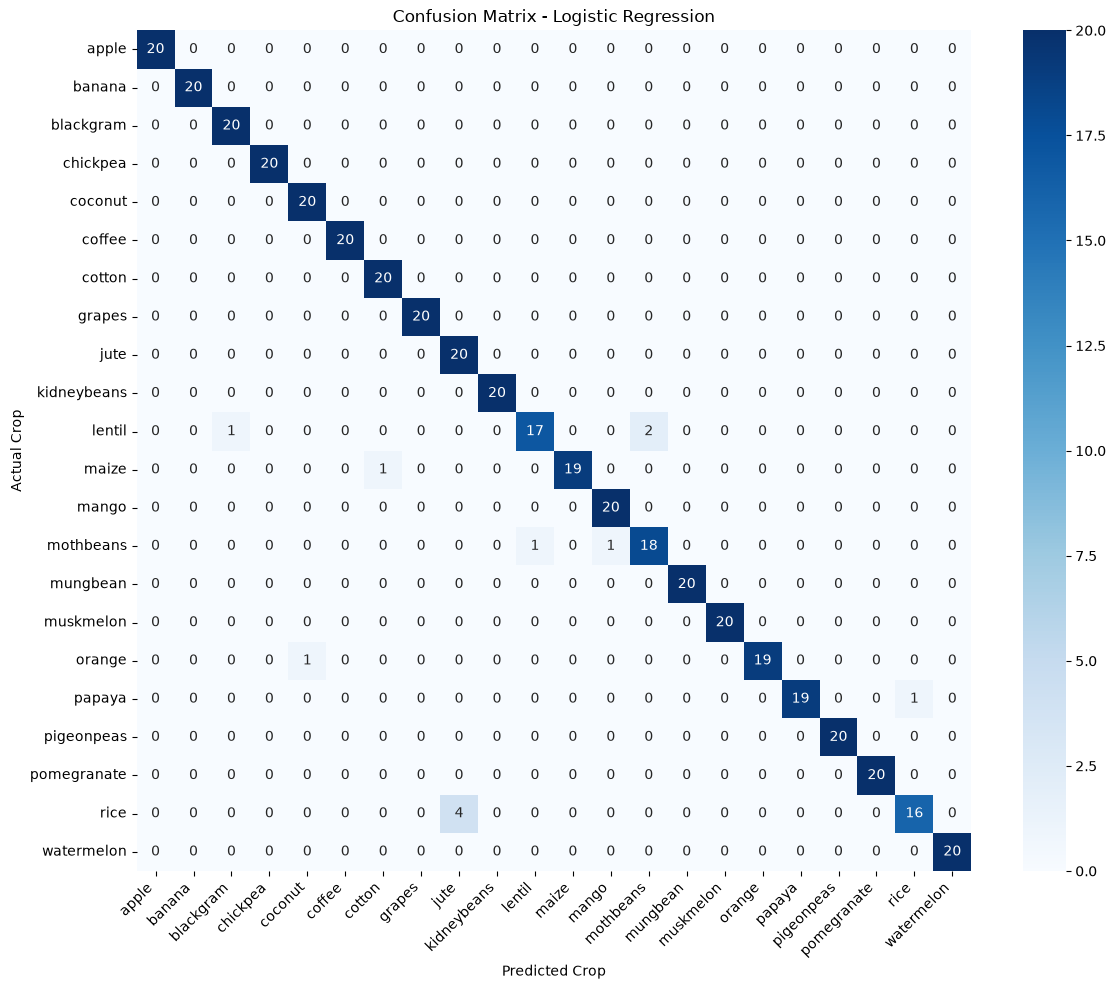

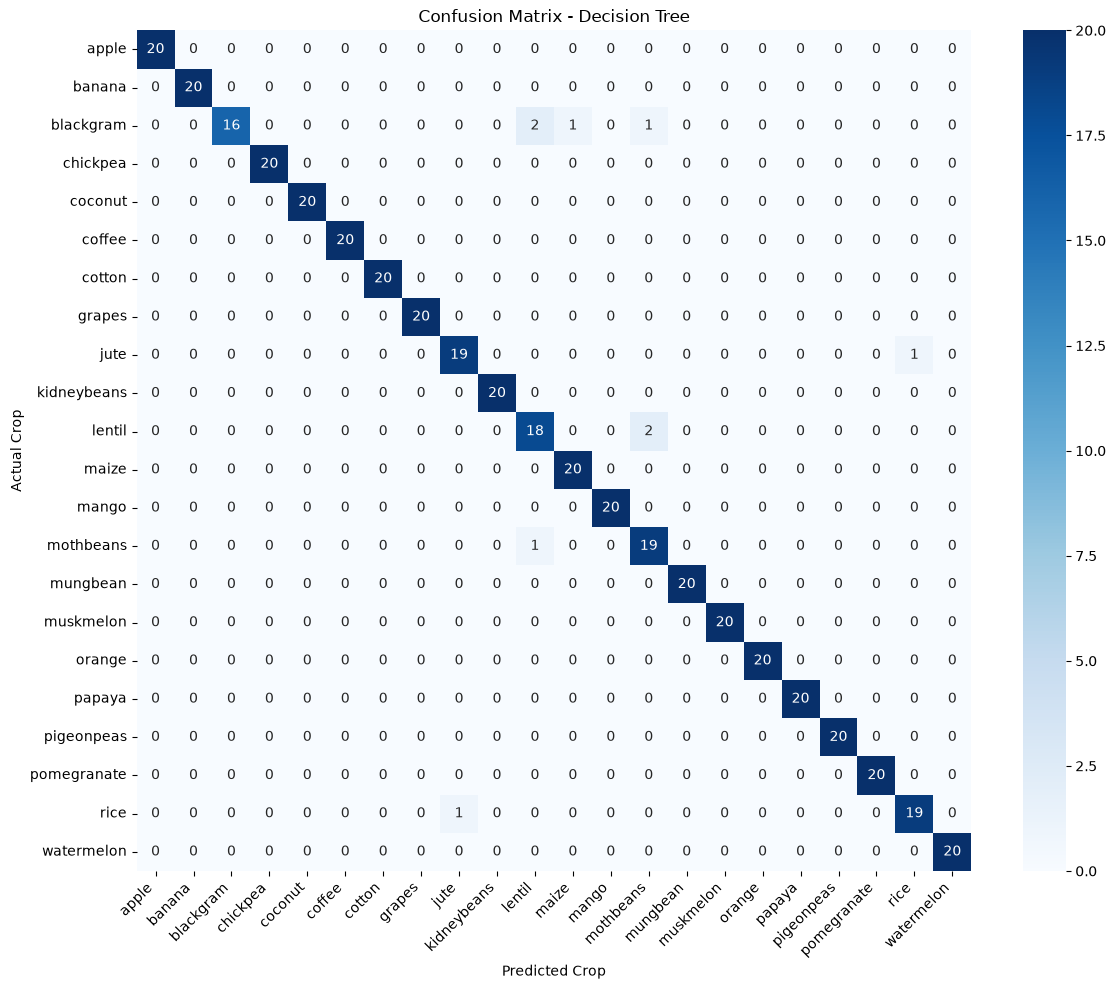

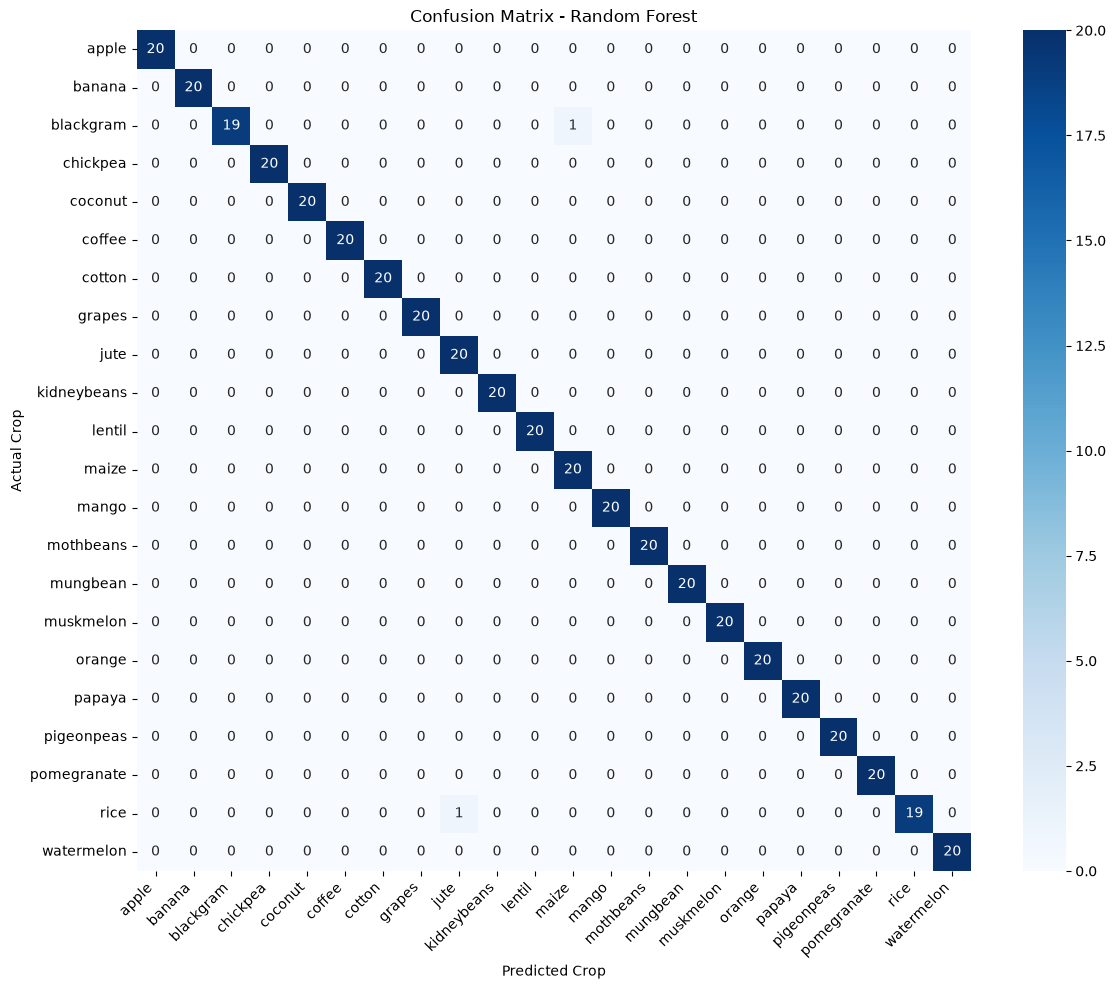

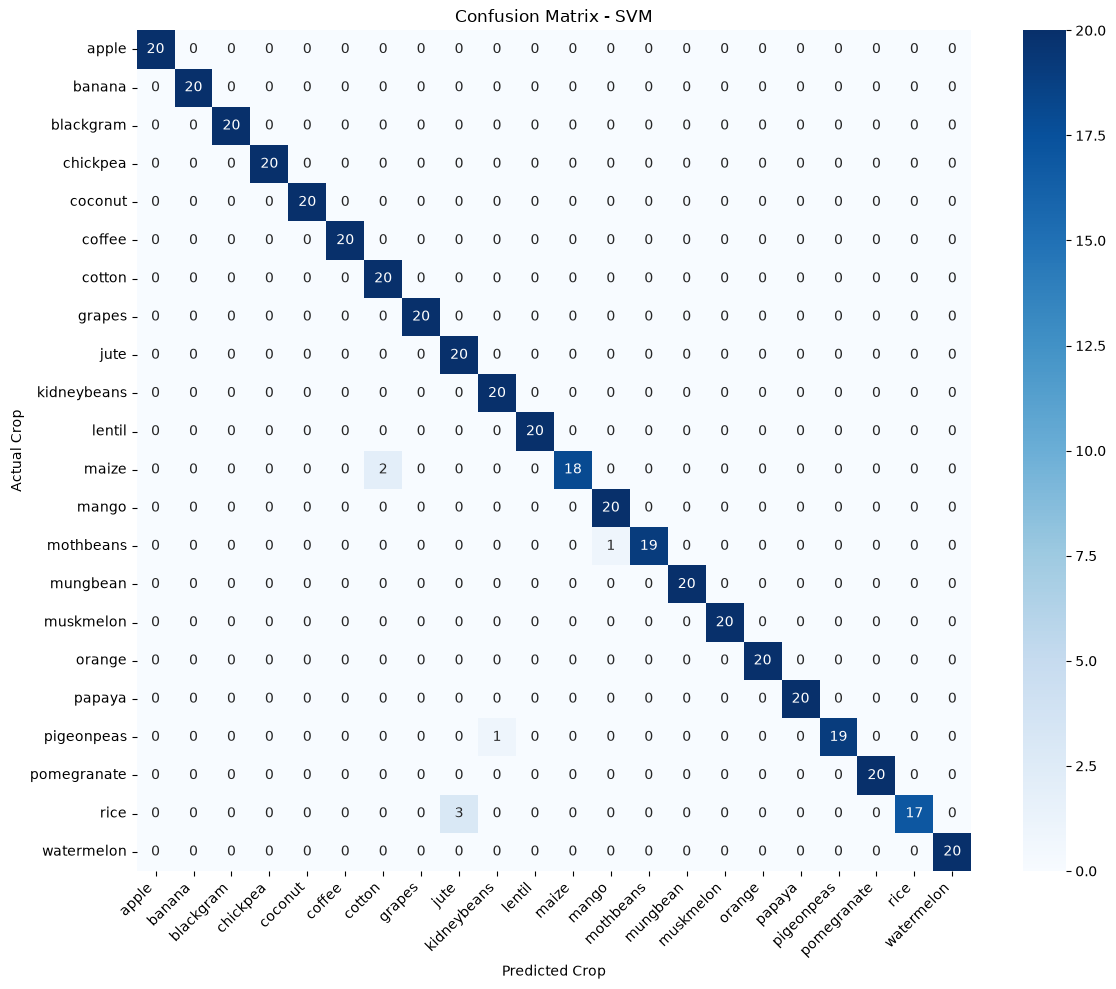

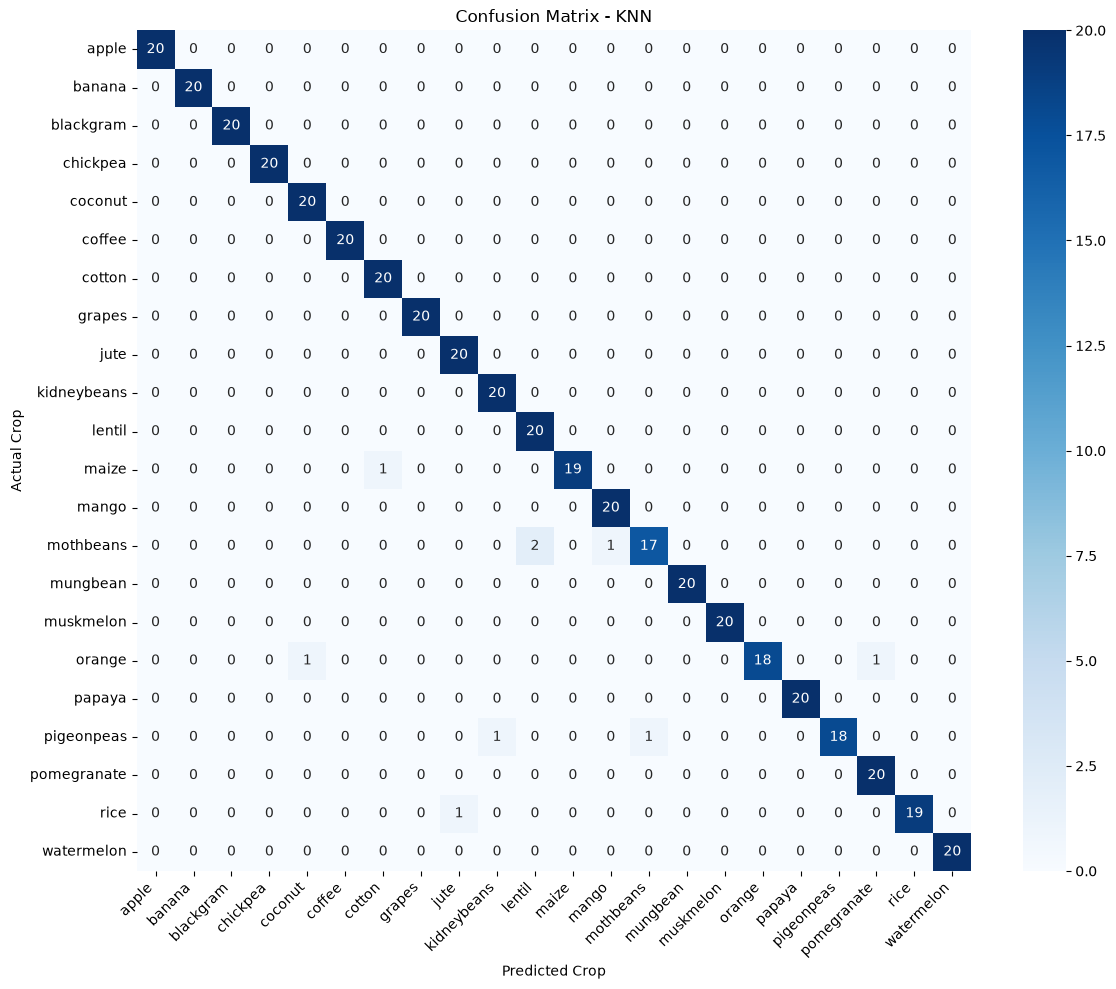

In [10]:
#CONFUSION MATRICES
import matplotlib.pyplot as plt
import seaborn as sns

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Crop")
    plt.ylabel("Actual Crop")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [11]:
#PRELIMINARY RESULTS
results_df.to_csv(
    "preliminary_model_results.csv",
    index=False
)

print("Preliminary model results saved successfully.")

Preliminary model results saved successfully.


In [12]:
#BEST PRELIMINARY MODEL
best_model = results_df.iloc[0]

print("Best Preliminary Model")
print("----------------------")
print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1-Score:", best_model["F1-Score"])

Best Preliminary Model
----------------------
Model: Random Forest
Accuracy: 0.9954545454545455
Precision: 0.9956709956709956
Recall: 0.9954545454545455
F1-Score: 0.9954517027687759


In [13]:
import os

print(os.getcwd())

C:\Users\suman\OneDrive\Desktop\Crop-Reco-ML\notebooks
